In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from dct_utils import *

In [2]:
sweep, sr_sweep = librosa.load("../samples/linear_sweep.wav", sr=None, mono=True)
sweep = sweep / np.max(np.abs(sweep))

frame_size   = 512
frame_psycho = 256
ratio        = 0.25
k_sweep      = int(frame_size   * ratio)
k_psycho     = int(frame_psycho * ratio)

print(f"sr={sr_sweep}Hz  długość={len(sweep)/sr_sweep:.1f}s")
print(f"frame={frame_size} k={k_sweep} ({ratio*100:.0f}%)")
print(f"frame_psycho={frame_psycho} k_psycho={k_psycho} ({ratio*100:.0f}%)")

sweep_results = {
    "DCT ramkowa":          compress_dct_frames(sweep, frame_size, k_sweep),
    "DCT + overlap":        compress_dct_overlap(sweep, frame_size, k_sweep),
    "DCT top-k":            compress_dct_topk(sweep, frame_size, k_sweep),
    "Psycho db=36":         compress_dct_psycho(sweep, sr_sweep, frame_psycho, k_psycho, spreading_db=36),
}

sr=44100Hz  długość=10.0s
frame=512 k=128 (25%)
frame_psycho=256 k_psycho=64 (25%)


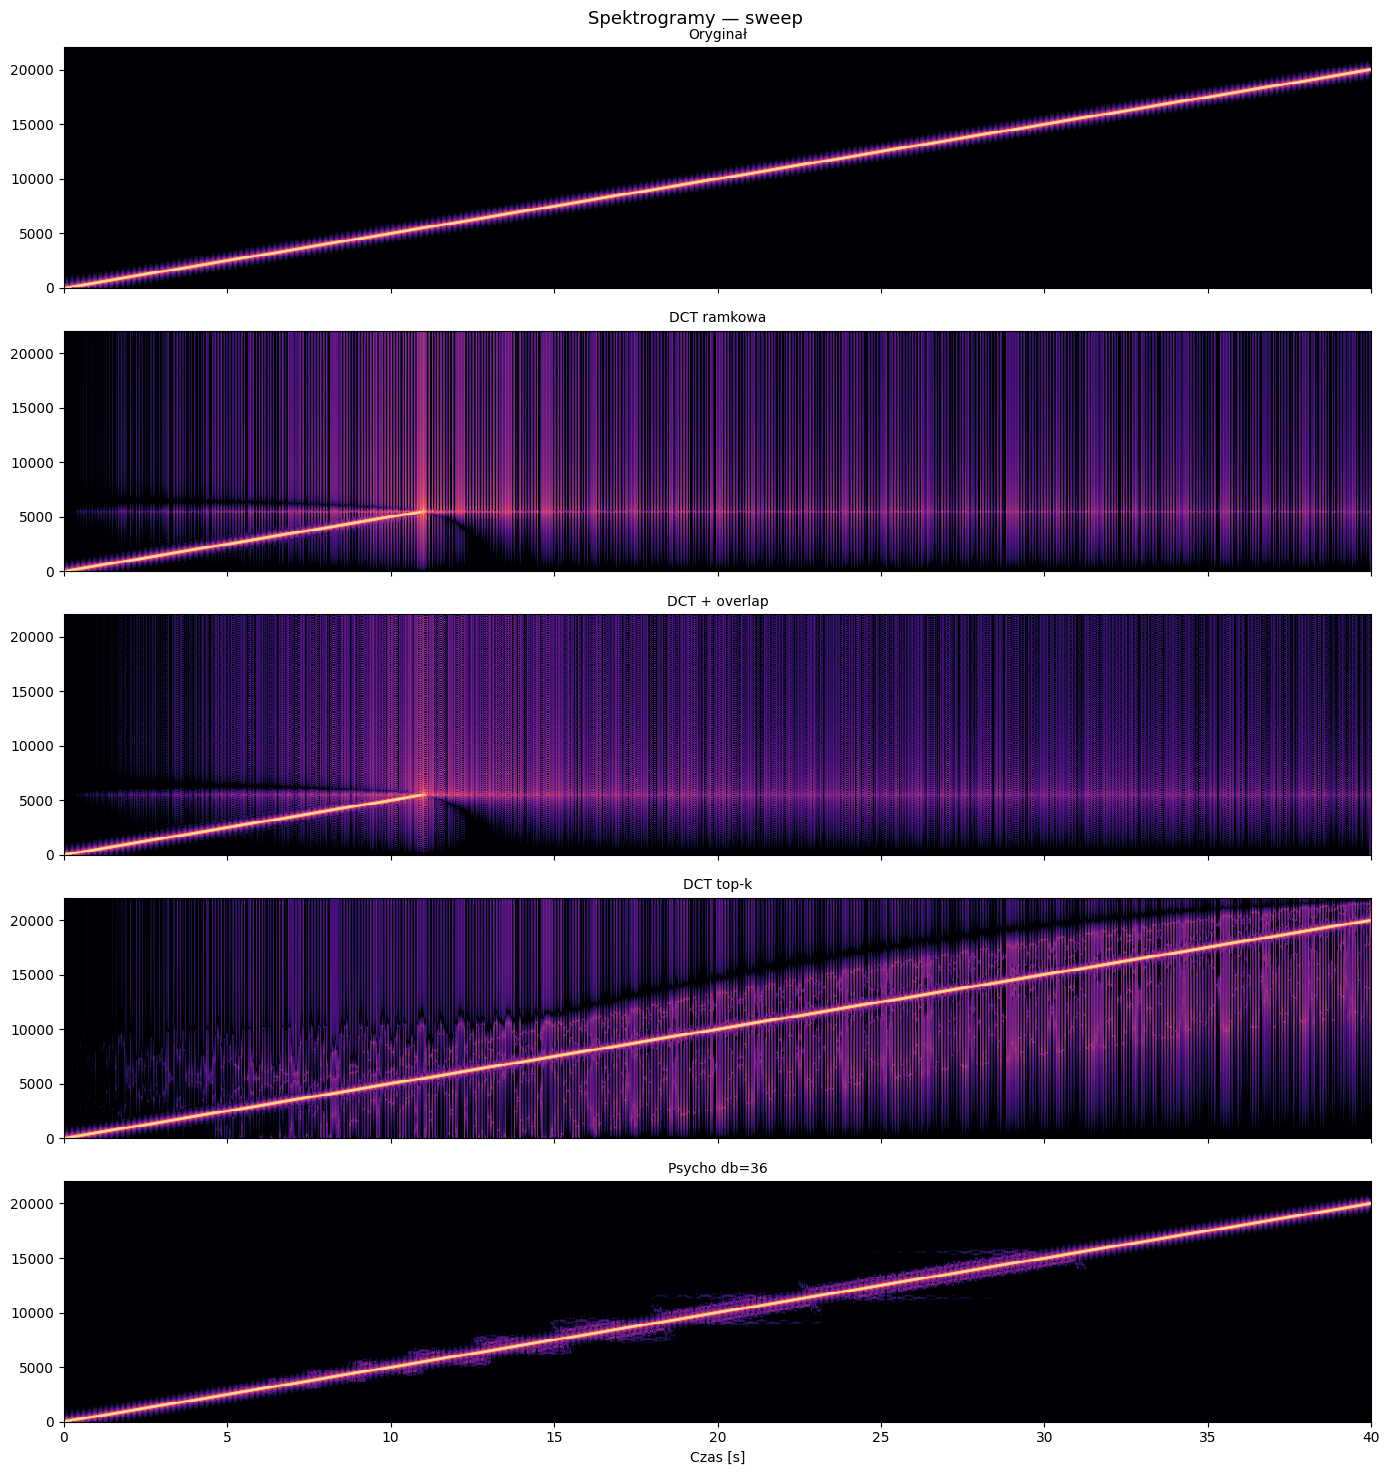

metryki: 

DCT ramkowa               SNR=1.4dB  LSD=55.8
DCT + overlap             SNR=1.4dB  LSD=51.2
DCT top-k                 SNR=29.0dB  LSD=54.9
Psycho db=36              SNR=38.7dB  LSD=22.5

analiza metryk: 

Oryginał                  0-500Hz:25.1%  500-2k:26.0%  2k-5k:26.0%  5k+:22.9%
                          brak wyraźnego cutoff

DCT ramkowa               0-500Hz:32.2%  500-2k:33.4%  2k-5k:33.4%  5k+:0.9%
                          cutoff ~5000 Hz  (5k+: 0.9% vs 22.9% oryginału, utracono 96%)

DCT + overlap             0-500Hz:32.3%  500-2k:33.5%  2k-5k:33.4%  5k+:0.9%
                          cutoff ~5000 Hz  (5k+: 0.9% vs 22.9% oryginału, utracono 96%)

DCT top-k                 0-500Hz:25.1%  500-2k:26.0%  2k-5k:26.0%  5k+:22.9%
                          brak wyraźnego cutoff

Psycho db=36              0-500Hz:25.1%  500-2k:26.0%  2k-5k:26.0%  5k+:22.9%
                          brak wyraźnego cutoff



In [3]:
fig, axes = plt.subplots(len(sweep_results) + 1, 1,
                          figsize=(14, 3 * (len(sweep_results) + 1)),
                          sharex=True)
fig.suptitle("Spektrogramy — sweep", fontsize=13)

def plot_spectrogram(ax, signal, sr, title):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(signal, n_fft=512)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, sr // 2)
    ax.set_ylabel("")
    ax.set_xlabel("")

plot_spectrogram(axes[0], sweep, sr_sweep, "Oryginał")
for i, (name, rec) in enumerate(sweep_results.items()):
    n = min(len(rec), len(sweep))
    plot_spectrogram(axes[i + 1], rec[:n], sr_sweep, name)

axes[-1].set_xlabel("Czas [s]")
plt.tight_layout()
plt.show()

print("metryki: \n")
for name, rec in sweep_results.items():
    snr = compute_snr(sweep, rec)
    lsd = log_spectral_distance(sweep, rec, sr_sweep)
    print(f"{name:25s} SNR={snr:.1f}dB  LSD={lsd:.1f}")

print("\nanaliza metryk: \n")

orig_D = np.abs(librosa.stft(sweep, n_fft=512))
freqs  = librosa.fft_frequencies(sr=sr_sweep, n_fft=512)
bands  = [(0, 500), (500, 2000), (2000, 5000), (5000, sr_sweep // 2)]

orig_band_energy = []
for f_low, f_high in bands:
    idx = (freqs >= f_low) & (freqs < f_high)
    orig_band_energy.append(np.mean(orig_D[idx, :] ** 2))
orig_total = sum(orig_band_energy) + 1e-12

for name, rec in [("Oryginał", sweep)] + list(sweep_results.items()):
    n   = min(len(rec), len(sweep))
    D   = np.abs(librosa.stft(rec[:n], n_fft=512))

    band_energy = []
    for f_low, f_high in bands:
        idx = (freqs >= f_low) & (freqs < f_high)
        band_energy.append(np.mean(D[idx, :] ** 2))
    total = sum(band_energy) + 1e-12

    print(f"{name:25s} "
          f"0-500Hz:{band_energy[0]/total*100:.1f}%  "
          f"500-2k:{band_energy[1]/total*100:.1f}%  "
          f"2k-5k:{band_energy[2]/total*100:.1f}%  "
          f"5k+:{band_energy[3]/total*100:.1f}%")

    ratio_spec  = np.mean(D, axis=1) / (np.mean(orig_D, axis=1) + 1e-12)
    cutoff_idx  = np.where(ratio_spec < 0.05)[0]
    energy_5k_pct     = band_energy[3] / total * 100
    orig_5k_pct       = orig_band_energy[3] / orig_total * 100
    energy_5k_ratio   = energy_5k_pct / (orig_5k_pct + 1e-12)

    if energy_5k_ratio < 0.1:
        print(f"{'':25s} cutoff ~5000 Hz  "
              f"(5k+: {energy_5k_pct:.1f}% vs {orig_5k_pct:.1f}% oryginału, "
              f"utracono {(1-energy_5k_ratio)*100:.0f}%)")
    elif len(cutoff_idx) > 0:
        print(f"{'':25s} cutoff ~{freqs[cutoff_idx[0]]:.0f} Hz")
    else:
        print(f"{'':25s} brak wyraźnego cutoff")
    print()

DCT ramkowa i overlap zachowują zawsze pierwsze k współczynników — czyli zawsze niskie częstotliwości. Sweep w górnych pasmach (5kHz+) ma swoje współczynniki daleko od zera w tablicy DCT, więc zostają wyrzucone. Stąd cutoff — koder dosłownie nie widzi wysokich częstotliwości.
top-k wybiera k współczynników o największej amplitudzie, nieważne gdzie się znajdują. Sweep w danej chwili ma tylko jedną dominującą częstotliwość — top-k ją zawsze trafi, czy to 50Hz czy 15kHz. Stąd brak cutoffu i dobry SNR.
Psycho robi to samo co top-k ale dodatkowo wie które współczynniki są percepcyjnie nieistotne — czyli małe w stosunku do dominującego tonu w danym paśmie Barksa. Wyrzuca je zanim jeszcze trafi do top-k. Efekt: te same k miejsc są lepiej wykorzystane — zamiast zachowywać szum i słabe harmoniczne, koder zachowuje tylko to co naprawdę słyszalne. Stąd mniej szumu przy tym samym budżecie k.